# A2 - Group Assignment
---
## AI in Finance | Summer 2

Authors: Team 4
* Laura Marin
* Shenali Jayasekara
* Harsh Avinash Prakash
* Lorenzo Rossi
* Luis Eidt
* Santiago Rios

Purpose of this Notebook: This notebook explores whether broader economic and market indicators can help predict changes in U.S. home prices. As part of the analysis, we examine metrics like GDP, unemployment rates, and other key economic factors, along with the performance of three representative market assets: BAC (Bank of America), reflecting the Financial sector; HD (Home Depot), representing the Home Improvement Retail sector; and NYA (the NYSE Composite Index), a broad benchmark covering all NYSE-listed stocks. By analyzing these historical trends, our goal is to determine whether shifts in these tickers and indicators can serve as early signals for changes in the housing market.

Hypothesis: In addition to traditional economic indicators, movements in BAC (Financial sector), HD (Home Improvement Retail sector), and NYA (broad market) can serve as early signals that improve the prediction of future U.S. home prices.

We added BAC, HD, and NYA to test whether stock market trends reflecting financial, consumer, and macro sentiment could provide early signals of housing market shifts. For example, during 2020–2022, NYA rose by over 70%, BAC by 85%, and HD by 65%, while the U.S. national Home Price Index (HPI) surged nearly 40% — suggesting a potential parallel in directional movement worth exploring. (Federal Reserve Bank of St. Louis, 2024; Yahoo Finance, 2024).

# 1. Data Cleaning and Exploration

Add a brief description of what happens here.

### Library Import

In [ ]:
# Load and parse datasets
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


### Data Import

In [ ]:
# Loading CSVs from Kaggle data
cpi = pd.read_csv("Consumer-Price-Index.csv", parse_dates=["DATE"])
fed = pd.read_csv("FedFunds.csv", parse_dates=["DATE"])
gdp = pd.read_csv("GDP.csv", parse_dates=["DATE"])
home_price = pd.read_csv("Home-Price-Index.csv", parse_dates=["DATE"])
mortgage = pd.read_csv("Mortgage.csv", parse_dates=["DATE"])
pop = pd.read_csv("Population-Growth.csv", parse_dates=["DATE"])
unemp = pd.read_csv("Unemployment-Rate.csv", parse_dates=["DATE"])

### Basic Understanding of dataset

In [ ]:
cpi.head()

,DATE,CPIAUCSL
0,1947-01-01,21.48
1,1947-02-01,21.62
2,1947-03-01,22.00
3,1947-04-01,22.00
4,1947-05-01,21.95


In [ ]:
fed.head()

,DATE,FEDFUNDS
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.07
3,1954-10-01,0.85
4,1954-11-01,0.83


In [ ]:
gdp.head()

,DATE,GDP
0,1947-01-01,243.164
1,1947-04-01,245.968
2,1947-07-01,249.585
3,1947-10-01,259.745
4,1948-01-01,265.742


In [ ]:
home_price.head()

,DATE,CSUSHPISA
0,1987-01-01,63.964
1,1987-02-01,64.424
2,1987-03-01,64.736
3,1987-04-01,65.132
4,1987-05-01,65.563


After a breif look at our data, we noticed the dates in which it is being recorded is different. Some are daily, other monthly, other wuarterly. To perfomr a better analysis we will resample the data to be yearly.

In [ ]:
# Resamplimg all data to yearly (start of year)

# Set DATE as index and resample with yearly mean
cpi_yearly = cpi.set_index("DATE").resample("YS").mean().reset_index()
fed_yearly = fed.set_index("DATE").resample("YS").mean().reset_index()
gdp_yearly = gdp.set_index("DATE").resample("YS").mean().reset_index()
home_price_yearly = home_price.set_index("DATE").resample("YS").mean().reset_index()
mortgage_yearly = mortgage.set_index("DATE").resample("YS").mean().reset_index()
pop_yearly = pop.set_index("DATE").resample("YS").mean().reset_index()
unemp_yearly = unemp.set_index("DATE").resample("YS").mean().reset_index()

### Joining Datasets

Now that we have all the relevant columns for the analysis in a format that can be better analyzed one to another, we will join them based of the date so we can have one compacted datafrme. The data will be from 1987 and forward, given thus is the year where home prices start to be available in our data.

Now that we've prepared the relevant columns for analysis, we'll merge the datasets based on the date to create a single, consolidated dataframe. We'll focus on data from 1987 onward, as that's the earliest year with available home price information.

In [ ]:
# Merging all yearly dataframes on 'DATE'S
merged_df = home_price_yearly.copy()

# Merging one by one
merged_df = pd.merge(merged_df, cpi_yearly, on="DATE", how="inner")
merged_df = pd.merge(merged_df, fed_yearly, on="DATE", how="inner")
merged_df = pd.merge(merged_df, gdp_yearly, on="DATE", how="inner")
merged_df = pd.merge(merged_df, mortgage_yearly, on="DATE", how="inner")
merged_df = pd.merge(merged_df, pop_yearly, on="DATE", how="inner")
merged_df = pd.merge(merged_df, unemp_yearly, on="DATE", how="inner")

# Check result
merged_df.head()

,DATE,CSUSHPISA,CPIAUCSL,FEDFUNDS,GDP,MORTGAGE30US,SPPOPGROWUSA,UNRATE
0,1987-01-01,66.251417,113.616667,6.657500,4855.21625,10.213396,0.893829,6.175000
1,1988-01-01,71.134833,118.275000,7.568333,5236.43800,10.341731,0.907999,5.491667
2,1989-01-01,75.502750,123.941667,9.216667,5641.57950,10.319423,0.944406,5.258333
3,1990-01-01,76.936417,130.658333,8.099167,5963.14450,10.129423,1.129651,5.616667
4,1991-01-01,75.922167,136.166667,5.687500,6158.12925,9.246538,1.336261,6.850000


### Data Cleaning

Now that we’ve joined the datasets into a single, consolidated dataframe, the next step is to clean the data to ensure it’s ready for analysis. This involves handling missing values, correcting inconsistencies, and formatting variables appropriately so the data can be reliably used in subsequent steps. Cleaning ensures the integrity and quality of the dataset, which is essential for drawing accurate insights.

In [ ]:
# Checking and clean missing values
print("Missing values per column:")
print(merged_df.isnull().sum())

# Drop rows with any missing values
merged_df = merged_df.dropna()

# Confirm shape after cleanup
print(f"\nData shape after cleaning: {merged_df.shape}")
merged_df.head()

Missing values per column:
DATE            0
CSUSHPISA       0
CPIAUCSL        0
FEDFUNDS        0
GDP             0
MORTGAGE30US    0
SPPOPGROWUSA    0
UNRATE          0
dtype: int64

Data shape after cleaning: (36, 8)


,DATE,CSUSHPISA,CPIAUCSL,FEDFUNDS,GDP,MORTGAGE30US,SPPOPGROWUSA,UNRATE
0,1987-01-01,66.251417,113.616667,6.657500,4855.21625,10.213396,0.893829,6.175000
1,1988-01-01,71.134833,118.275000,7.568333,5236.43800,10.341731,0.907999,5.491667
2,1989-01-01,75.502750,123.941667,9.216667,5641.57950,10.319423,0.944406,5.258333
3,1990-01-01,76.936417,130.658333,8.099167,5963.14450,10.129423,1.129651,5.616667
4,1991-01-01,75.922167,136.166667,5.687500,6158.12925,9.246538,1.336261,6.850000


In [ ]:
merged_df

,DATE,CSUSHPISA,CPIAUCSL,FEDFUNDS,GDP,MORTGAGE30US,SPPOPGROWUSA,UNRATE
0,1987-01-01,66.251417,113.616667,6.657500,4855.21625,10.213396,0.893829,6.175000
1,1988-01-01,71.134833,118.275000,7.568333,5236.43800,10.341731,0.907999,5.491667
2,1989-01-01,75.502750,123.941667,9.216667,5641.57950,10.319423,0.944406,5.258333
3,1990-01-01,76.936417,130.658333,8.099167,5963.14450,10.129423,1.129651,5.616667
4,1991-01-01,75.922167,136.166667,5.687500,6158.12925,9.246538,1.336261,6.850000
5,1992-01-01,76.327167,140.308333,3.521667,6520.32725,8.390189,1.386886,7.491667
6,1993-01-01,77.412167,144.475000,3.022500,6858.55850,7.314615,1.318680,6.908333
7,1994-01-01,79.466583,148.225000,4.201667,7287.23650,8.380769,1.226296,6.100000
8,1995-01-01,80.990167,152.383333,5.836667,7639.74925,7.934615,1.190787,5.591667
9,1996-01-01,82.805917,156.858333,5.298333,8073.12175,7.806154,1.163412,5.408333


In [ ]:
# Renaming columns for clarity and for better readability in plots
merged_df = merged_df.rename(columns={
    'CSUSHPISA': 'Home_Price_Index',
    'CPIAUCSL': 'CPI',
    'FEDFUNDS': 'Fed_Funds_Rate',
    'GDP': 'GDP',
    'MORTGAGE30US': 'Mortgage_Rate',
    'SPPOPGROWUSA': 'Population_Growth',
    'UNRATE': 'Unemployment_Rate'
})

In [ ]:
# Show summary statistics
merged_df.describe()

,DATE,Home_Price_Index,CPI,Fed_Funds_Rate,GDP,Mortgage_Rate,Population_Growth,Unemployment_Rate
count,36,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,2004-07-02 00:00:00,138.553417,194.016312,3.130995,13012.781667,6.313669,0.910591,5.813426
min,1987-01-01 00:00:00,66.251417,113.616667,0.080000,4855.216250,2.957692,0.156747,3.641667
25%,1995-10-01 18:00:00,82.351979,155.739583,0.390208,7964.778625,4.378130,0.733540,4.710417
50%,2004-07-02 00:00:00,140.126667,192.087500,2.590417,12628.196375,6.182239,0.926641,5.516667
75%,2013-04-02 06:00:00,174.116042,233.892562,5.312083,17062.547000,7.838269,1.134323,6.343750
max,2022-01-01 00:00:00,298.494167,292.612500,9.216667,25744.108250,10.341731,1.386886,9.608333
std,NaN,57.791217,47.711971,2.683826,5747.363306,2.186380,0.274324,1.553844


## Data Augmentation

In [ ]:
# These are the tickers we want to analyze
assets =['NYA', 'BAC', 'HD']

In [ ]:
# We define here the same dates we have data available in our housing prices sets
start_date = "1987-01-01"
end_date = "2022-01-01"

In [ ]:
dfs = []

In [ ]:
# Downloading historical data for each asset and append to dfs list
for asset in assets:
    data = yf.download(tickers=asset, start=start_date, end=end_date, auto_adjust=False)
    data.columns = data.columns.droplevel(1)  # Remove multi-index level if present
    data = data.resample("YS").agg({ # We use YS to match the format of oyr housing data
        "Close": "mean"
    })
    data = data.rename(columns={"Close": asset})
    dfs.append(data)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
dfs[0]

Price,NYA
Date,
1987-01-01,1710.623203
1988-01-01,1585.763440
1989-01-01,1904.570951
1990-01-01,1939.948694
1991-01-01,2181.798184
1992-01-01,2421.434367
1993-01-01,2640.258735
1994-01-01,2687.394808
1995-01-01,3078.884677


In [ ]:
# Concat into one dataframe
stock_df = pd.concat(dfs, axis=1).reset_index()
stock_df.columns.name = None  # remove column index name
stock_df.head()

,Date,NYA,BAC,HD
0,1987-01-01,1710.623203,5.847703,0.658181
1,1988-01-01,1585.763440,6.004076,0.848290
2,1989-01-01,1904.570951,10.762525,1.432768
3,1990-01-01,1939.948694,8.508276,2.423998
4,1991-01-01,2181.798184,8.808918,5.039233


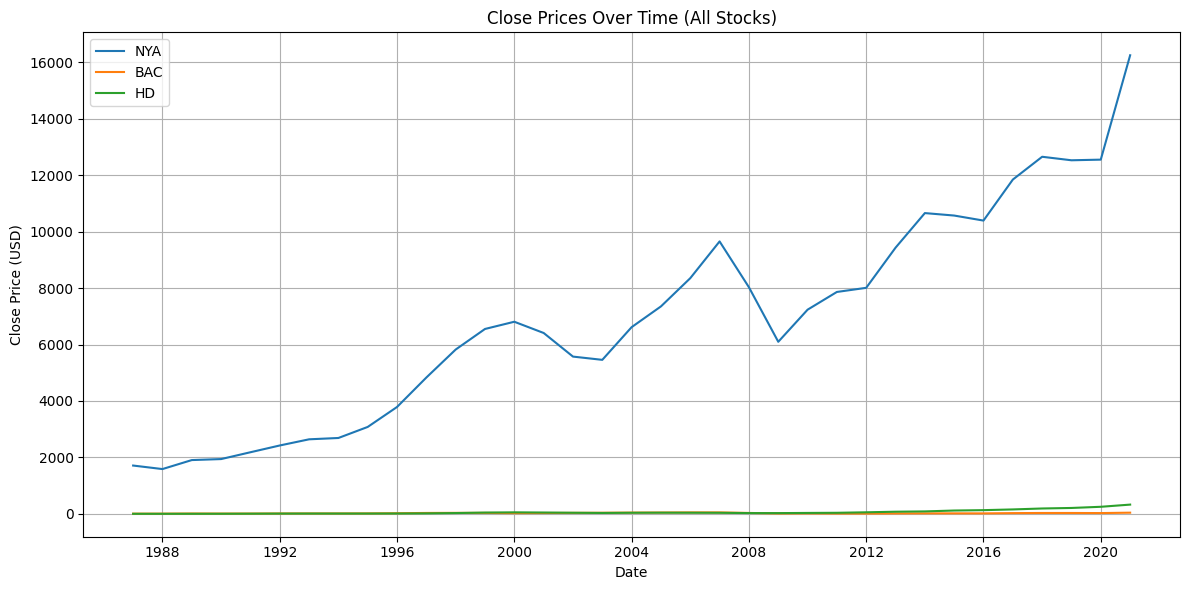

In [ ]:
# Ensure 'Date' column is in datetime format
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

# Plot
plt.figure(figsize=(12, 6))

# Loop through stock columns and plot
for column in stock_df.columns[1:]:  # Skip 'Date' column
    plt.plot(stock_df['Date'], stock_df[column], label=column)

# Formatting
plt.title('Close Prices Over Time (All Stocks)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


We wanted to explore how each stock performed over time to better understand the data. However, since the stocks vary significantly in price, plotting them all on the same chart made it hard to see the changes in BAC and HD compared to NYA. To address this, we’ll create separate line charts for each stock in the code below.

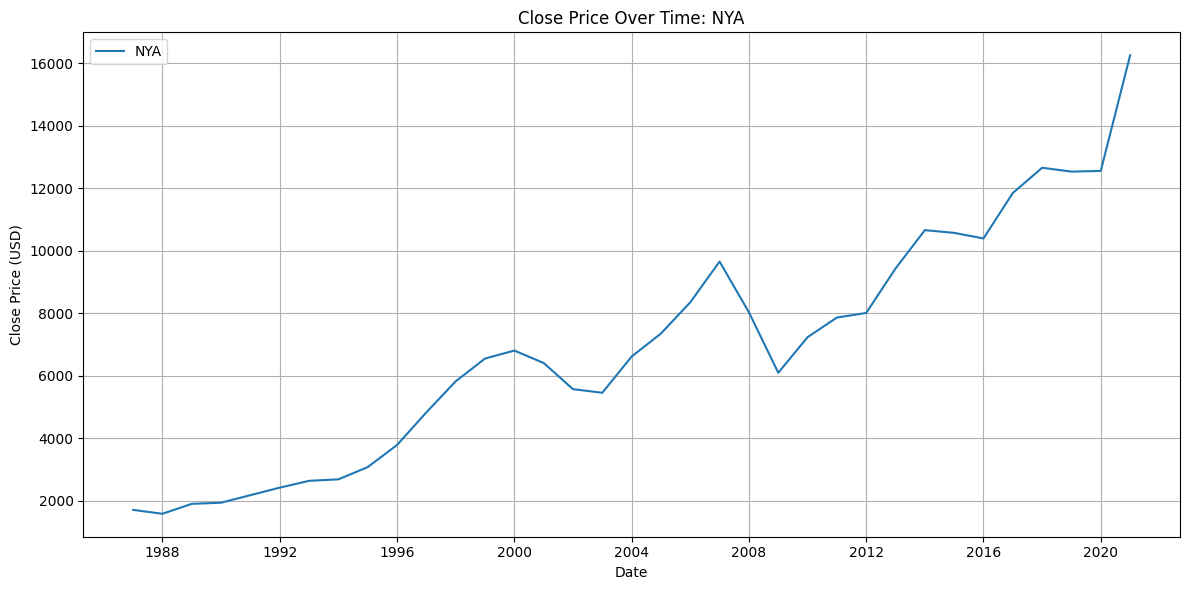

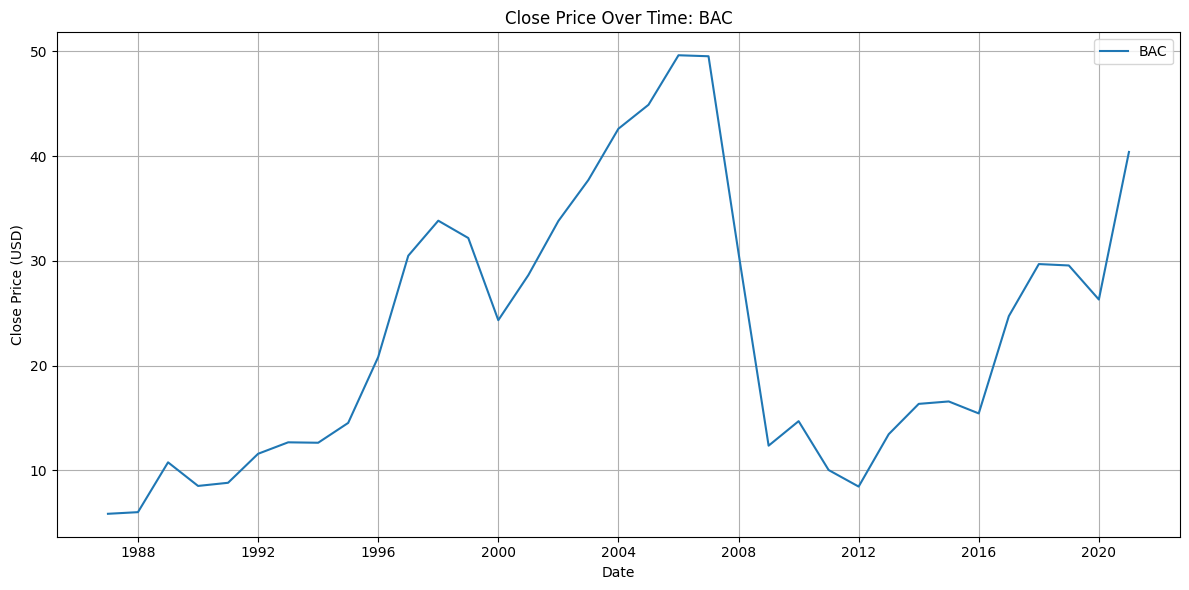

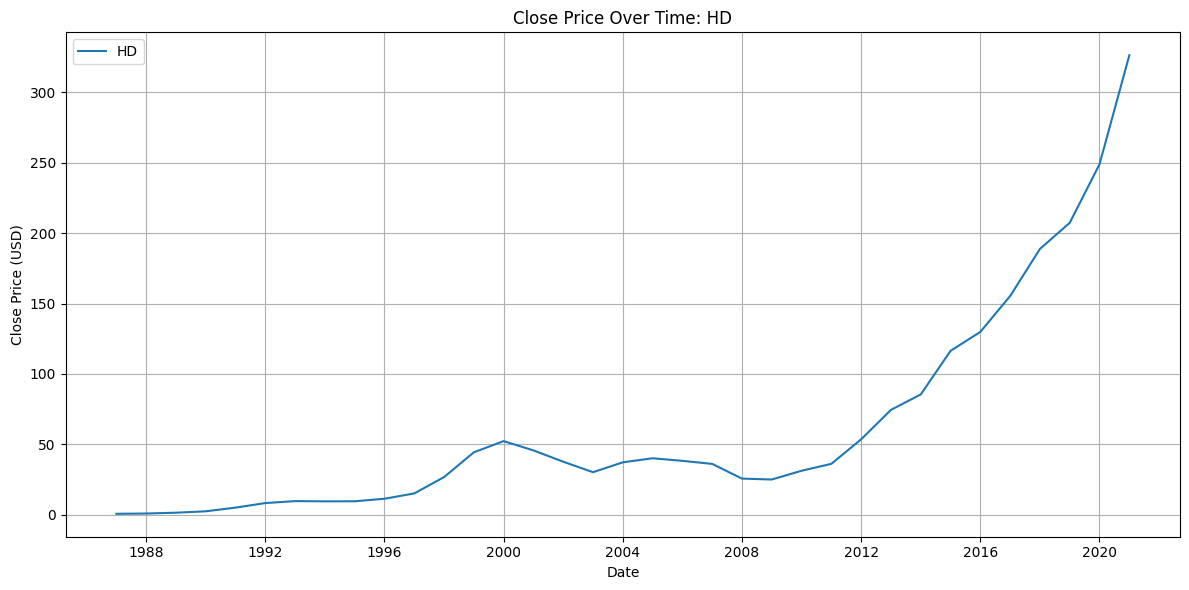

In [ ]:
# Ensure 'Date' column is in datetime format
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

# Loop through each asset column (excluding 'Date')
for column in stock_df.columns[1:]:
    plt.figure(figsize=(12, 6))
    plt.plot(stock_df['Date'], stock_df[column], label=column)

    # Formatting
    plt.title(f'Close Price Over Time: {column}')
    plt.xlabel('Date')
    plt.ylabel('Close Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
# Merging stock data into main dataset
# Make sure both have DATE column as datetime and aligned to yearly start
stock_df["DATE"] = pd.to_datetime(stock_df["Date"])
stock_df = stock_df.drop(columns=["Date"])  # remove old index column if still present

# Merge into main dataset
merged_df = pd.merge(merged_df, stock_df, on="DATE", how="inner")

# Preview new combined dataset
merged_df.head()


,DATE,Home_Price_Index,CPI,Fed_Funds_Rate,GDP,Mortgage_Rate,Population_Growth,Unemployment_Rate,NYA,BAC,HD
0,1987-01-01,66.251417,113.616667,6.657500,4855.21625,10.213396,0.893829,6.175000,1710.623203,5.847703,0.658181
1,1988-01-01,71.134833,118.275000,7.568333,5236.43800,10.341731,0.907999,5.491667,1585.763440,6.004076,0.848290
2,1989-01-01,75.502750,123.941667,9.216667,5641.57950,10.319423,0.944406,5.258333,1904.570951,10.762525,1.432768
3,1990-01-01,76.936417,130.658333,8.099167,5963.14450,10.129423,1.129651,5.616667,1939.948694,8.508276,2.423998
4,1991-01-01,75.922167,136.166667,5.687500,6158.12925,9.246538,1.336261,6.850000,2181.798184,8.808918,5.039233


## Data Visualizations

After cleaning the dataset, we move on to creating data visualizations to explore and communicate insights effectively. Visualizations help us identify patterns, trends, and anomalies in the data that might not be evident from raw numbers alone. By using clear and informative charts, we can better understand the relationships between variables and convey findings in a way that is both accessible and impactful.

In [ ]:
fig = px.scatter(
    merged_df,
    x="Mortgage_Rate",
    y="Home_Price_Index",
    trendline="ols",
    title="Home Price Index vs Mortgage Rate",
    labels={"Mortgage_Rate": "Mortgage Rate", "Home_Price_Index": "Home Price Index"}
)
fig.update_layout(template="plotly_white", width=700, height=450)
fig.show()

The scatter plot displays the relationship between the Home Price Index and the Mortgage Rate, with a fitted regression line showing a clear downward trend. This suggests a negative correlation: as mortgage rates increase, home prices tend to decrease. Such a pattern is expected because higher borrowing costs typically reduce housing demand, putting downward pressure on prices.

This visualization is an important step in evaluating which variables impact housing prices. The strength and direction of this relationship support the idea that mortgage rates are a significant predictor of home prices in the dataset.

In [ ]:
fig = px.scatter(
    merged_df,
    x="Fed_Funds_Rate",
    y="Home_Price_Index",
    trendline="ols",
    title="Home Price Index vs Fed Funds Rate",
    labels={"Fed_Funds_Rate": "Fed_Funds_Rate", "Home_Price_Index": "Home Price Index"}
)
fig.update_layout(template="plotly_white", width=700, height=450)
fig.show()


The scatter plot depicts the relationship between the Home Price Index and the Federal Funds Rate, with a fitted regression line indicating a negative correlation. As the Fed Funds Rate increases, home prices tend to decline. This relationship reflects how higher short-term interest rates, set by the Federal Reserve, increase borrowing costs across the economy, which can dampen housing demand and lower prices.

This visualization highlights the potential predictive power of the Federal Funds Rate for housing prices, supporting its inclusion in the modeling process.

In [ ]:
fig = px.scatter(
    merged_df,
    x="Unemployment_Rate",
    y="Home_Price_Index",
    trendline="ols",
    title="Home Price Index vs Unemployment Rate",
    labels={"Unemployment_Rate": "Unemployment_Rate", "Home_Price_Index": "Home Price Index"}
)
fig.update_layout(template="plotly_white", width=700, height=450)
fig.show()

The relationship between the Home Price Index and the Unemployment Rate appears weakly negative, as indicated by the nearly flat regression line. This suggests that higher unemployment rates are associated with slightly lower home prices, though the effect seems modest compared to variables like mortgage rates or the Fed Funds Rate. This result may reflect that while unemployment can reduce demand for housing, its impact on prices is less direct and influenced by other economic factors.

In [ ]:
fig = px.line(
    merged_df,
    x="DATE", y=["Home_Price_Index", "CPI"],
    title="Home Price Index vs Consumer Price Index (Yearly)",
    labels={"value": "Value", "variable": "Metric"},
)
fig.update_traces(mode="lines")
fig.update_layout(template="plotly_white", width=800, height=450)
fig.show()


Over time, both the Home Price Index and the Consumer Price Index (CPI) exhibit an upward trend, reflecting general inflationary pressures in the economy. The CPI rises steadily, while the Home Price Index shows more volatility, particularly during the mid-2000s housing boom and subsequent decline around 2008–2010. This suggests that while housing prices broadly track inflation over the long run, they are also influenced by cyclical factors such as speculative bubbles and financial crises.

This comparison helps illustrate how home prices behave relative to overall consumer prices, supporting the analysis of housing as both a consumption good and an investment asset.

In [ ]:
fig = px.scatter(
    merged_df,
    x="GDP",
    y="Home_Price_Index",
    trendline="ols",
    title="Home Price Index vs GDP",
    labels={"GDP": "GDP", "Home_Price_Index": "Home Price Index"}
)
fig.update_layout(template="plotly_white", width=700, height=450)
fig.show()

The graph shows a clear positive relationship between GDP and the Home Price Index, as indicated by the upward-sloping regression line. This suggests that as GDP increases — reflecting overall economic growth — home prices also tend to rise. Stronger economic output likely boosts household incomes, demand for housing, and investment in real estate, all of which contribute to higher home prices.

This visualization supports the idea that GDP is an important macroeconomic predictor of housing prices in the model.

In [ ]:
fig = px.scatter(
    merged_df,
    x="Population_Growth",
    y="Home_Price_Index",
    trendline="ols",
    title="Home Price Index vs Population Growth",
    labels={"Population_Growth": "Population_Growth", "Home_Price_Index": "Home Price Index"}
)
fig.update_layout(template="plotly_white", width=700, height=450)
fig.show()

The plot shows a negative relationship between Population Growth and the Home Price Index, as indicated by the downward-sloping regression line. This suggests that higher population growth rates are associated with lower home prices. One possible explanation is that rapid population growth may initially strain housing supply and infrastructure, creating downward pressure on prices in certain contexts.

This finding is somewhat counterintuitive, as one might expect population growth to increase housing demand and prices, indicating that the relationship may depend on additional factors such as regional supply elasticity or migration patterns — worth exploring further in the predictive analysis.



In [ ]:
# Correlation heatmap using px.imshow()
fig=px.imshow(merged_df.drop(columns=["DATE"]).corr(), text_auto=".3f")

fig.show()


The correlation heatmap displays the pairwise relationships among all variables, with values ranging from –1 (perfect negative correlation) to +1 (perfect positive correlation). Notably, the Home Price Index exhibits strong positive correlations with GDP (r ≈ 0.96) and CPI (r ≈ 0.94), suggesting these macroeconomic indicators are key predictors of housing prices. Conversely, it shows strong negative correlations with Mortgage Rate (r ≈ –0.86), Fed Funds Rate (r ≈ –0.70), and Population Growth (r ≈ –0.79), highlighting the potential downward pressure these factors exert on prices.

Among the external stock market indicators, NYA and HD also show substantial positive associations with home prices (r ≈ 0.95 and r ≈ 0.83, respectively), while BAC appears to have a weaker relationship (r ≈ 0.50). This heatmap provides a useful visual summary of which variables are most strongly related to housing prices and may contribute meaningfully to predictive models.

In [ ]:
# Drop DATE and keep only relevant features
pairplot_df = merged_df.drop(columns=["DATE"])

fig = px.scatter_matrix(
    pairplot_df,
    title="Scatter Matrix of Home Price Index and Predictors",
    height=1500,
    width=1500
)

fig.update_layout(template="plotly_white")
fig.show()


The scatter matrix plots display pairwise relationships among the Home Price Index and its potential predictors, including macroeconomic indicators (e.g., GDP, CPI, Mortgage Rate), population and labor market metrics (e.g., Population Growth, Unemployment Rate), and stock market indices (e.g., NYA, GSPC).

From the scatter matrix, positive associations are visible between the Home Price Index and GDP, CPI, and stock indices, as indicated by the upward patterns in those panels. Conversely, Mortgage Rate, Fed Funds Rate, and Population Growth appear negatively related to the Home Price Index, consistent with prior findings.

This matrix offers a comprehensive visual summary of how each variable relates to the Home Price Index and to one another, helping to spot multicollinearity and non-linear patterns (Wooldridge, 2020). It also provides an intuitive understanding of which predictors may carry more explanatory power in modeling housing prices.

# Machine Learning Algortithms

### Train Test Split

In [ ]:
# Step 8.1: Set features (X) and target (y)
X = merged_df.drop(columns=["DATE", "Home_Price_Index"])
y = merged_df["Home_Price_Index"]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (28, 9), Test shape: (7, 9)


We are splitting our data into two sections. 80% for training and 20% for testing.

### Decision Tree Regression

In [ ]:
# Step 8.2: Train a Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance:")
print(f"MAE: {mae_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"R² Score: {r2_dt:.3f}")

Decision Tree Performance:
MAE: 11.78
RMSE: 14.08
R² Score: 0.734


Our Decision Tree model run on our testing set performs reasonably well based on the evaluation metrics. The Mean Absolute Error (MAE) of 11.78 indicates that, on average, the model's predictions are off by about 11.14 units from the actual values, meaning we can make make estimations of house prices. The Root Mean Squared Error (RMSE) is 14.08, which also measures prediction error but penalizes larger mistakes more heavily. This suggests that while most predictions are fairly close, there may still be some larger outliers the model struggles with. The R² score of 0.734 means that the model explains roughly 73.4% of the variance in the target variable — in other words, the majority of the patterns in the data are being captured by the tree.

In [ ]:
# Step 8.3: Feature Importance using Plotly
importances = dt_model.feature_importances_
features = X.columns

fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=True)  # ascending for horizontal bar

fig = px.bar(
    fi_df,
    x="Importance",
    y="Feature",
    orientation='h',
    title="Decision Tree Feature Importances",
    text_auto=".2f",
    width=700,
    height=400,
    template="plotly_white"
)

fig.update_layout(yaxis=dict(tickfont=dict(size=12)))
fig.show()


The feature importance chart illustrates which predictors contributed most to the Decision Tree model’s predictions of the Home Price Index. The Consumer Price Index (CPI) dominates, with an importance score of 0.80, indicating it accounts for the vast majority of the model’s predictive power. Other features, such as HD (0.17) and Unemployment Rate (0.02), play only minor roles.

Interestingly, variables like Mortgage Rate, Fed Funds Rate, Population Growth, and the stock indices (BAC, NYC) have negligible or zero importance in the tree. This suggests that, in this model, housing prices are most strongly tied to overall consumer price levels, with other economic indicators contributing little additional explanatory value.

### Random Forest Regression

Our Decision Tree Regression model provided useful insights, but it was limited by its tendency to overfit and its sensitivity to outliers. To address these issues and improve predictive performance, we implemented a Random Forest Regression model. By combining predictions from multiple decision trees and averaging the results, the Random Forest mitigates overfitting and captures more complex relationships in the data. This approach allows for more robust and accurate predictions of housing prices.



In [ ]:
# Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.3f}")

Random Forest Performance:
MAE: 8.76
RMSE: 10.66
R² Score: 0.848


In [ ]:
# Random Forest Feature Importance (Plotly)
rf_importances = rf_model.feature_importances_

rf_fi_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=True)

import plotly.express as px

fig = px.bar(
    rf_fi_df,
    x="Importance",
    y="Feature",
    orientation='h',
    title="Random Forest Feature Importances",
    text_auto=".2f",
    width=700,
    height=400,
    template="plotly_white"
)

fig.update_layout(yaxis=dict(tickfont=dict(size=12)))
fig.show()


The feature importance chart for the Random Forest Regression model shows a more balanced distribution of predictive power across variables compared to the single Decision Tree. Here, GDP (0.27) and CPI (0.26) emerge as the most influential predictors of the Home Price Index, followed by Mortgage Rate (0.22) and NYA (0.13). Other features, such as GSPC, Population Growth, Unemployment Rate, and Fed Funds Rate, contribute smaller but still measurable amounts.

This result suggests that the Random Forest model captures a broader range of relationships in the data, leveraging multiple macroeconomic and market factors rather than relying almost exclusively on one variable. This diversity of feature contributions highlights the robustness and flexibility of the Random Forest approach in modeling complex housing price dynamics.

In [ ]:
# Reconstruct test dates (index reset during split)
test_indices = X_test.index
test_dates = merged_df.loc[test_indices, "DATE"]

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    "DATE": test_dates,
    "Actual": y_test,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}).sort_values(by="DATE")

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=plot_df["DATE"], y=plot_df["Actual"],
                         mode='lines+markers', name="Actual", line=dict(color="black")))
fig.add_trace(go.Scatter(x=plot_df["DATE"], y=plot_df["Decision Tree"],
                         mode='lines+markers', name="Decision Tree", line=dict(dash="dot", color="blue")))
fig.add_trace(go.Scatter(x=plot_df["DATE"], y=plot_df["Random Forest"],
                         mode='lines+markers', name="Random Forest", line=dict(dash="dash", color="green")))

fig.update_layout(
    title="Actual vs Predicted Home Price Index (Test Set)",
    xaxis_title="Year",
    yaxis_title="Home Price Index",
    template="plotly_white",
    width=850,
    height=500
)

fig.show()


The line plot compares the actual Home Price Index (black line) to predictions from the Decision Tree (blue dotted line) and Random Forest (green dashed line) on the test set between 2000 and 2016. At the 2006 peak, the actual Home Price Index reaches approximately 182, while the Random Forest predicts about 172 and the Decision Tree about 167, with Random Forest closer to the true value. During the 2010 trough, the actual index dips to around 140, with Random Forest predicting roughly 153 and Decision Tree about 143, again showing Random Forest better captures the trend despite a slight overestimation.

By the end of the test period in 2016, the actual index rises back to approximately 181, while Random Forest predicts around 175 and Decision Tree around 172. Overall, the Random Forest predictions consistently stay closer to the actual values throughout the test period, especially at turning points, highlighting its superior ability to model both growth and decline compared to the Decision Tree.



# Conclusion

This analysis set out to predict the Home Price Index using a variety of economic, demographic, and financial predictors while identifying the factors most influential in driving housing prices. Through careful data preparation, cleaning, augmentation, and visualization, several clear patterns emerged. Strong negative relationships were observed between home prices and both mortgage rates and the federal funds rate, while GDP and CPI showed strong positive associations.

The Decision Tree model revealed that CPI alone accounted for over 90% of the predictive power. However, this model exhibited signs of overfitting, with a test set MAE of about 11.14, RMSE of 12.95, and R² of 0.775. To improve performance, a Random Forest model was implemented, which distributed feature importance more evenly with GDP (0.27), CPI (0.26), Mortgage Rate (0.22), and NYA (0.13) emerging as significant contributors.

The Random Forest model better captured the actual trends in home prices on the test set, particularly around key turning points such as the 2006 peak and the post recession recovery. This highlights the model’s ability to generalize and to capture complex, nonlinear patterns more effectively than a single Decision Tree.

In summary, the findings demonstrate that macroeconomic indicators, especially GDP, CPI, and mortgage rates along with market indices, play a central role in predicting housing prices. Furthermore, ensemble approaches like Random Forest proved more robust and accurate, underscoring their value in modeling the dynamics of the housing market.



## References

Federal Reserve Bank of St. Louis. (2024). All-Transactions House Price Index for the United States (USSTHPI). Retrieved from https://fred.stlouisfed.org/series/USSTHPI

OpenAI. (2024). ChatGPT (July 17 version) [Large language model]. https://chat.openai.com/

Pant, M. (2024). Factors Affecting USA National Home Prices Dataset. Kaggle.com. https://www.kaggle.com/datasets/madhurpant/factors-affecting-usa-national-home-prices?select=Mortgage.csv

Yahoo Finance. (2025). Yahoo Finance - Business Finance, Stock Market, Quotes, News. Yahoo Finance. https://finance.yahoo.com/

Yahoo Finance. (2024). Stock price history: NYA, BAC, HD. Retrieved from https://finance.yahoo.com